# Imports

In [1]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import cv2
from scipy.stats import ks_2samp

# Methods

In [4]:
def apply_fourier_transform(image):
    """Aplica a Transformada de Fourier a uma imagem e retorna a magnitude e a transformada."""
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude = np.log(np.abs(f_shift) + 1)
    return magnitude, f_shift

In [5]:
def filtro_passa_baixa(img, sigma):
    """Aplica um filtro passa-baixa na imagem usando a transformada de Fourier"""
    # Aplicar a Transformada de Fourier
    dft = np.fft.fft2(img)

    # Calculando valores para aplicar no filtro passa baixa
    nx = dft.shape[1]
    ny = dft.shape[0]

    cxrange = np.concatenate(
        (
            np.arange(0, nx // 2 + 1),
            np.arange(-nx // 2 + 1, 0)
        )
    )
    cyrange = np.concatenate(
        (
            np.arange(0, ny // 2 + 1),
            np.arange(-ny // 2 + 1, 0)
        )
    )
    cx, cy = np.meshgrid(cxrange, cyrange)

    fxrange = cxrange * 2 * (np.pi / nx)
    fyrange = cyrange * 2 * (np.pi / ny)

    fx, fy = np.meshgrid(fxrange, fyrange)
    return np.exp(-(fx**2 + fy**2) / (2 * (sigma**2)))

# Parameters

In [6]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / 'atv03_lista-final'

# Questão 01

In [7]:
def read_img(file_path: str):
    """Lendo imagem em escala de cinza"""
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    return img

def apply_fourier_transform(image):
    """Aplica a transformada de Fourier e retorna a magnitude e a transformada deslocada"""
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude = np.log(np.abs(f_shift) + 1)
    return magnitude, f_shift

In [ ]:
imgs = {
    "Pattern1": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern1.png'),
        "img_fft": None
    },
    "Pattern1_blur": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern1_blur.png'),
        "img_fft": None
    },
    "Pattern1_blur2": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern1_blur2.png'),
        "img_fft": None
    },
    "Pattern2": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern2.png'),
        "img_fft": None
    },
}
for key, value in imgs.items():
    imgs[key]["img_fft"] = apply_fourier_transform(value["img"])[0]

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))
for i, (key, img) in enumerate(imgs.items()):
    ax[i // 2, i % 2].imshow(img["img"], cmap='gray')
    ax[i // 2, i % 2].set_title(key)
    ax[i // 2, i % 2].axis('off')


## A)

In [ ]:
lista_imgs = [
    "Pattern1",
    "Pattern2",
]

fig = plt.figure(figsize=(16, 18))
axes = []
for i in range(2):
    axes.append(fig.add_subplot(3, 2, i + 1))
    axes.append(fig.add_subplot(3, 2, i + 3))
    axes.append(fig.add_subplot(3, 2, i + 5, projection='3d'))

for i, key in enumerate(lista_imgs):
    # Imagem original
    axes[i * 3].imshow(imgs[key]["img"], cmap='gray')
    axes[i * 3].set_title(key)
    axes[i * 3].axis('off')

    # FFT 2D
    axes[i * 3 + 1].imshow(imgs[key]["img_fft"], cmap='gray')
    axes[i * 3 + 1].set_title(key + " - FFT")
    axes[i * 3 + 1].axis('off')

    # FFT 3D
    fft_magnitude = imgs[key]["img_fft"]
    x = np.arange(fft_magnitude.shape[1])
    y = np.arange(fft_magnitude.shape[0])
    X, Y = np.meshgrid(x, y)
    axes[i * 3 + 2].plot_surface(X, Y, fft_magnitude, cmap='jet')
    axes[i * 3 + 2].set_title(key + " - FFT 3D")

fig.tight_layout()
fig.savefig(path_assets / "atv03_q01-01.png", dpi=400)

## B)

In [ ]:
lista_imgs = [
    "Pattern1",
    "Pattern1_blur",
    "Pattern1_blur2",
]

fig = plt.figure(figsize=(16, 18))
axes = []

# Criando eixos para imagens 2D e FFT
for i in range(3):  # 3 colunas
    axes.append(fig.add_subplot(3, 3, i + 1))  # Linha 1: Imagens originais
    axes.append(fig.add_subplot(3, 3, i + 4))  # Linha 2: FFT 2D
    axes.append(fig.add_subplot(3, 3, i + 7, projection='3d'))  # Linha 3: FFT 3D

for i, key in enumerate(lista_imgs):
    # Imagem original
    axes[i * 3].imshow(imgs[key]["img"], cmap='gray')
    axes[i * 3].set_title(key)
    axes[i * 3].axis('off')

    # FFT 2D
    axes[i * 3 + 1].imshow(imgs[key]["img_fft"], cmap='gray')
    axes[i * 3 + 1].set_title(key + " - FFT")
    axes[i * 3 + 1].axis('off')

    # FFT 3D
    fft_magnitude = imgs[key]["img_fft"]
    x = np.arange(fft_magnitude.shape[1])
    y = np.arange(fft_magnitude.shape[0])
    X, Y = np.meshgrid(x, y)
    axes[i * 3 + 2].plot_surface(X, Y, fft_magnitude, cmap='jet')
    axes[i * 3 + 2].set_title(key + " - FFT 3D")

fig.tight_layout()
fig.savefig(path_assets / "atv03_q01-02.png", dpi=400)
plt.show()

# Questão 02

In [ ]:
image = cv2.imread(path_imgs_atv / "Q2" / "XRay.png", cv2.IMREAD_GRAYSCALE)
range_values = [i for i in range(0, 256, 85)]

In [ ]:
[i for i in range(0, 256, 85)]

In [ ]:
image = cv2.imread(path_imgs_atv / "Q2" / "XRay.png", cv2.IMREAD_GRAYSCALE)


# Definir kernel Laplaciano
kernel = np.array(
    [
        [0, 1, 1, 0],
        [1, -2, -2, 1],
        [1, -2, -2, 1],
        [0, 1, 1, 0]
    ]
)

# Aplicar o filtro Laplaciano na imagem quantizada
laplacian = cv2.filter2D(image_quant, cv2.CV_64F, kernel)
laplacian_abs = cv2.convertScaleAbs(laplacian)

# Exibir resultado
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(image_quant, cmap='gray')
plt.title("Quantizada por Intervalos")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(laplacian_abs, cmap='gray')
plt.title("Laplaciano na Quantizada")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image = cv2.imread(path_imgs_atv / "Q2" / "XRay.png", cv2.IMREAD_GRAYSCALE)

# Definir kernel Laplaciano manualmente
kernel = np.array(
    [
        [0, 1, 1, 0],
        [1, -2, -2, 1],
        [1, -2, -2, 1],
        [0, 1, 1, 0]
    ]
)

# Aplicar o filtro Laplaciano com o kernel definido
laplacian_custom = cv2.filter2D(image, cv2.CV_64F, kernel)
laplacian_abs = cv2.convertScaleAbs(laplacian_custom)

kernel = np.ones((5,5),np.uint8)


######
# Aplique um fechamento (dilatação seguida de erosão) para fechar pequenas lacunas
laplacian_abs = cv2.morphologyEx(laplacian_abs, cv2.MORPH_CLOSE, kernel)
#################

# Equalização de histograma sobre o resultado do Laplaciano
laplacian_eq = cv2.equalizeHist(laplacian_abs)


range_values = [i for i in range(0, 256, 127)]

# Criar uma cópia da imagem para modificar
image_quant = np.zeros_like(laplacian_eq)

# Para cada faixa, atribuir o valor mínimo do intervalo
for i in range(len(range_values) - 1):
    mask = (image >= range_values[i]) & (image < range_values[i + 1])
    image_quant[mask] = range_values[i]
# Para o último intervalo (inclui o valor máximo 255)
image_quant[image >= range_values[-1]] = range_values[-1]

laplacian_eq = image_quant
# kernel = np.ones((12, 12), np.uint8)
# laplacian_eq = cv2.erode(laplacian_eq, kernel, iterations=5)

# Use a proper uint8 kernel for morphology

# Binarizar para preencher ossos
_, mask = cv2.threshold(laplacian_abs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Exibir resultados
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
# fig, ax = plt.subplots(1, 4, figsize=(18, 6))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(laplacian_abs, cmap='gray')
ax[1].set_title("Laplaciano (kernel customizado)")
ax[1].axis("off")
ax[2].imshow(laplacian_eq, cmap='gray')
ax[2].set_title("Laplaciano Equalizado")
ax[2].axis("off")
# ax[3].imshow(mask, cmap='gray')
# ax[3].set_title("Laplaciano Equalizado")
# ax[3].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Destacar apenas os ossos: ossos em preto (ou valor original), fundo branco

# Inverter a máscara para que ossos sejam 0 (preto) e fundo 255 (branco)
mask_inv = cv2.bitwise_not(mask)

# Criar imagem branca
highlight = np.full_like(image, 255)

# Copiar os ossos (onde mask==255) da imagem original para a imagem branca
highlight[mask == 255] = image[mask == 255]

# Exibir resultado
plt.figure(figsize=(8, 6))
plt.imshow(highlight, cmap='gray')
plt.title("Ossos Destacados (fundo branco)")
plt.axis("off")
plt.show()

In [ ]:
image = cv2.imread(path_imgs_atv / "Q2" / "XRay.png", cv2.IMREAD_GRAYSCALE)
_, image_bin = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Criar o kernel para o fechamento
kernel = np.ones((7, 7), np.uint8)

# Aplicar o Abertura
image_processed = cv2.morphologyEx(image_bin, cv2.MORPH_OPEN, kernel)

# Exibir a imagem original, o histograma e a imagem após o fechamento
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Imagem Original")
ax[0].axis('off')

ax[1].hist(image.flatten(), bins=150)
ax[1].set_title("Histograma")
ax[1].spines[["top", "right"]].set_visible(False)
ax[1].axvline(x=65, color='r', linestyle='--', label='Limiar')

ax[2].imshow(image_processed, cmap='gray')
ax[2].set_title("Imagem com Fechamento")
ax[2].axis('off')

fig.suptitle("[Mão] Abertura com Kernel 7x7")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q02-01.png", dpi=400)
plt.show()

# Questão 03

## [Logica] Agrupando tons semelhante


Como mencionado na questão, uma solução para a redução da quantidade de cores das imagens pode ser pelo meio de agrupamento de tons semelhantes para cada canal. A logica para o algoritmo esta abaixo:


* **1)**

In [ ]:
# Caminho para a imagem
images_path = {
    "araras": path_imgs_atv / "Q3" / "araras.png",
    "F1": path_imgs_atv / "Q3" / "F1.png",
    "green-water": path_imgs_atv / "Q3" / "green-water.png",
    "surf": path_imgs_atv / "Q3" / "surf.png",
}

imgs = {}
for key, path in images_path.items():
    img = cv2.imread(path)
    imgs[key] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
def count_colores(
        image: np.ndarray
    ) -> int:
    """
    Conta o número de cores únicas em uma imagem RGB.

    Args:
        image (np.ndarray): Imagem RGB.

    Returns:
        int: Número de cores únicas.
    """
    # Converte a imagem para um array 2D
    pixels = image.reshape(-1, 3)
    # Conta as cores únicas
    unique_colors = np.unique(pixels, axis=0)
    return unique_colors.shape[0]

def reduce_colors(
        image: np.ndarray,
        bins: int = 4
    ) -> np.ndarray:
    """
    Reduz a quantidade de cores de uma imagem RGB, agrupando tons semelhantes.

    Args:
        image (np.ndarray): Imagem RGB.
        bins (int): Número de intervalos para quantização em cada canal (R, G, B).

    Returns:
        np.ndarray: Imagem com cores reduzidas.
    """
    # Calcula os limites dos intervalos
    bin_edges = np.linspace(
        0,
        256,
        bins + 1,
        dtype=np.int32
    )
    bin_centers = (
        (bin_edges[:(-1)] + bin_edges[(1):]) / 2
    ).astype(int)
    
    # Mapeia cada pixel para o centro do intervalo correspondente
    quantized_image = np.zeros_like(image)
    for i in range(3):  # Para cada canal (R, G, B)
        channel = image[:, :, i]
        indices = np.digitize(channel, bin_edges) - 1
        quantized_image[:, :, i] = bin_centers[indices]

    return quantized_image, bin_centers, bin_edges

def adjust_bins(
        image: np.ndarray,
        list_range: list=[50, 150],
        target_range: tuple = (1/3, 0.5)
    ) -> int:
    """
    Ajusta o número de bins para garantir que a quantidade de cores reduzidas
    esteja dentro do intervalo desejado.

    Args:
        image (np.ndarray): Imagem RGB.
        list_range (list): Intervalo de bins a serem testados (mínimo, máximo).
        target_range (tuple):
            Intervalo desejado (mínimo, máximo) como fração da quantidade de cores originais.

    Returns:
        int: Número de bins ajustado.
    """
    original_colors = count_colores(image)
    min_colors = int(original_colors * target_range[0])  # min % do numero de cores
    max_colors = int(original_colors * target_range[1])  # max % do numero de cores

    # Testar diferentes números de bins até atingir o intervalo desejado
    for bins in range(*list_range):
        reduced_image, _, _ = reduce_colors(image, bins)
        reduced_colors = count_colores(reduced_image)
        if min_colors <= reduced_colors <= max_colors:
            return bins

    # Caso não encontre, retorna o máximo de bins permitido
    return np.min(list_range)

In [ ]:
# Aplicar a redução de cores nas imagens
reduced_imgs = {}
bins_per_image = {}
for key, img in imgs.items():
    # Ajustar dinamicamente os bins para cada imagem
    bin = adjust_bins(
        img,
        list_range=[50, 150, 10],  # parametro de procura de bins
        target_range=(1 / 3, 0.5)  # parametro de stop
    )#(1/3, 0.5))
    bins_per_image[key] = bin
    reduced_imgs[key] = reduce_colors(img, bins=bin)

In [ ]:
for key, img in reduced_imgs.items():
    img = img[0]
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path_assets / f"atv03_q03-reduced-{key}.png"), img_bgr)

In [ ]:
# Exibir as imagens originais e reduzidas
fig, ax = plt.subplots(len(reduced_imgs), 2, figsize=(16, 10))

for idx, (key, img) in enumerate(reduced_imgs.items()):
    count_original = count_colores(imgs[key])
    count_reduced = count_colores(img[0])
    count_perc = 100 * (count_reduced / count_original)

    # Imagem original
    ax[idx, 0].imshow(imgs[key])
    ax[idx, 0].set_title(f"{key} - Original ({count_original} cores)")
    ax[idx, 0].axis("off")

    # Imagem reduzida
    ax[idx, 1].imshow(img[0])
    ax[idx, 1].set_title(f"{key} - Reduzida ({count_reduced} cores | {count_perc:.2f}%)")
    ax[idx, 1].axis("off")

fig.tight_layout()
fig.savefig(path_assets / "atv03_q03_reduced_colors.png", dpi=400)
plt.show()

# Questão 04

In [ ]:
imgs = {
    "Textura1": {
        "img": read_img(path_imgs_atv / "Q4" / 'Textura1.png'),
        "img_fft": None
    },
    "Textura2": {
        "img": read_img(path_imgs_atv / "Q4" / 'Textura2.png'),
        "img_fft": None
    },
    "Textura3": {
        "img": read_img(path_imgs_atv / "Q4" / 'Textura3.png'),
        "img_fft": None
    },
}
for key, value in imgs.items():
    imgs[key]["img_fft"] = apply_fourier_transform(value["img"])[0]

In [ ]:
fig = plt.figure(figsize=(16, 12))
axes = []
for i in range(3):
    axes.append(fig.add_subplot(3, 3, i + 1))
    axes.append(fig.add_subplot(3, 3, i + 4))
    axes.append(fig.add_subplot(3, 3, i + 7, projection="3d"))

for i, (key, img) in enumerate(imgs.items()):
    # Imagem original
    axes[i * 3].imshow(img["img"], cmap="gray")
    axes[i * 3].set_title(key)
    axes[i * 3].axis("off")

    # FFT 2D
    axes[i * 3 + 1].imshow(img["img_fft"], cmap="gray")
    axes[i * 3 + 1].set_title(key + " - FFT")
    axes[i * 3 + 1].axis("off")

    # FFT 3D
    fft_magnitude = img["img_fft"]
    x = np.arange(fft_magnitude.shape[1])
    y = np.arange(fft_magnitude.shape[0])
    X, Y = np.meshgrid(x, y)
    axes[i * 3 + 2].plot_surface(X, Y, fft_magnitude, cmap="jet")
    axes[i * 3 + 2].set_title(key + " - FFT 3D")

# Ajustar layout
fig.tight_layout()
fig.savefig(path_assets / "atv03_q04-01.png", dpi=400)
plt.show()

## Solução 01) Coeficiente de varição


Vamos analisar, em conjunto, a variabilidade em torno da média da transformada de fourier, utilizando do **Coeficiente de Variação**, cuja formula pode ser expressa abaixo


$$
CV_{\%} = \frac{\sigma}{\mu} \cdot 100
$$

aonde 

$$
\begin{cases}
\sigma: \text{ Desvio padrão da magnitude da transformada de fourier} \\
\mu: \text{ Média da magnitude da transformada de fourier}
\end{cases}
$$

Para tanto, considerando que o problema é binário, vamos fixar a imagem 1 (*Textura1*) como sendo uma referencia para a classe 1, e um threshold de permissão de 5% de variabilidade sobre essa imagem de referência, para que aquela textura pertença a classe 1. Vamos por partes, abaixo calculamos o desvio padrão para cada Textura.

In [ ]:
stats_values = {}
for key, value in imgs.items():
    stats_values[key] = {
        "media": float(value["img_fft"].mean()),
        "desvio": float(value["img_fft"].std())
    }
    stats_values[key]["cv"] = 100 * (stats_values[key]["desvio"] / stats_values[key]["media"])

data_stats = pd.DataFrame(stats_values).round(2)
data_stats

Dado os coeficientes de variação acima, como definido antes, vamos utilizar o coeficiente de variação da imagem *Textura1* como referência, ou seja, 19.43%. Dessa forma, com 5% de permissão de variabilidade sobre o coeficiente de variação, temos o limite superior de 19.43% + 5% = 24.43% e limite inferior de 19.43% - 5% = 14.43%, ou seja, para que a textura seja da classe 1, então o coeficiente de variação da imagem deve estar entre  temos definido a regra abaixo:

$$
\begin{cases}
i\in \text{Classe 1}: \text{ se } 14.43 \leq cv_{i} \leq 24.43 \\
i\in \text{Classe 2}: \text{ se } cv_{i} \leq 14.43 \text{ ou } cv_{i} \geq 24.43
\end{cases}
$$

Por fim, temos um método automático para decisão se a textura exibida pertence ao mesmo padrão da 1 e da 2, ou seja, a classe 1.

Este método considera a variabilidade entre os valores de frequências na matriz de magnitudes de fourier, considerando o percentual de variabilidade em torno da média. Dessa forma, o algoritmo leva em consideração a média dos pixels e o desvio padrão da imagem.

## Solução 02) Mean Absolute Percentage Error

É possivel também, utilizando a *Textura1* como  padrão para comparação sobre a classe 1, também podemos aplicar calculos matemáticos para comparar uma nova textura com a imagem utilizada. Dessa forma, vamos utilizar a métrica conhecida como *Mean Absolute Percentage Error* (MAPE), para compararmos novas texturas com a escolhida para representar a classe 1.


A formula para o MAPE, adaptada para a situação matricial, pode ser expressa abaixo:

$$
MAPE_{\%} = 100 \cdot \sum_{j = 1}^{m}\sum_{i = 1}^{n}  \frac{|y_{ij} - \hat{y}_{ij}|}{|y_{ij}|}
$$

sendo:

$$
\begin{cases}
y_{ij}: \text{ i-ésima linha e j-ésima coluna da matriz de transformada de fourier para a matriz de referência} \\
\hat{y}_{ij}: \text{ i-ésima linha e j-ésima coluna da matriz de transformada de fourier para a matriz de comparação}
\end{cases}
$$

Será necessário considerar também um threshold para garantir um comportamento parecido entre ambas frequências na matriz de magnitude de fourier. Vamos considerar um threshold de 25% para que seja considerado uma imagem similar a de comparação, ou seja, se MAPE<sub>%</sub> < 25%, então a imagem pertence a classe 1; caso contrário, pertence a classe 2.

$$
\begin{cases}
i \in \text{Classe 1}: \text{ se } MAPE_{\%} \leq 25\% \\
i \in \text{Classe 2}: \text{ se } MAPE_{\%} > 25\%
\end{cases}
$$

Abaixo, vamos calcular esses valores:

In [ ]:
def mape(y_true, y_pred):
    """Calcula o erro percentual médio absoluto (MAPE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

img_refer = "Textura1"
data_mapes = {}
for key in ["Textura2", "Textura3"]:
    data_mapes[key] = {
        "mape": mape(
            imgs[img_refer]["img_fft"].flatten(),
            imgs[key]["img_fft"].flatten()
        )
    }
data_mapes = pd.DataFrame(data_mapes).round(2)
data_mapes

Acima, podemos ver que para a *Textura2* o valor de MAPE foi inferior ao threshold escolhido, então podemos afirmar que essa textura pertence a classe 1 também, já a *Textura3*, o valor é superior, logo pela regra sera considerado da classe 2.

Com todas as regras definidas, temos bem claro um algoritmo automático para decisão a qual classe a textura pertence.

## Solução 03) Estatística de Komolgorov-Smirnov 

In [ ]:
def ecdf(data):
    """Calcula a distribuição acumulada empírica (ECDF)."""
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cumulative

img_refer = "Textura1"
ecdfs = {}
distances = {}
# Plots
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
for key, img in imgs.items():
    dist = img["img_fft"].flatten()
    x, y = ecdf(dist)
    ecdfs[key] = {"x": x, "y": y}
    # Plotar a Distribuição de Densidade de Kernel (KDE)
    sns.kdeplot(dist, label=f"{key} - KDE", fill=True, alpha=0.3, ax=ax[0])
    
    # Calculo da estatística KS
    if key != img_refer:
        distances[key] = {
            "ks": float(ks_2samp(imgs[img_refer]["img_fft"].flatten(), dist).statistic)
        }

    # Plotar a Função de Densidade Acumulada (CDF)
    if key != img_refer:
        ax[1].plot(
            x,
            y,
            label="{} - ECDF - Distance: {:.2f}".format(key, distances[key]['ks']),
            linestyle="--"
        )
    else:
        ax[1].plot(
            x,
            y,
            label=f"{key} - ECDF",
            linestyle="--"
        )


# Configurar o gráfico
ax[0].set_title("Distribuição e Densidade Acumulada das Magnitudes da FFT")
ax[0].set_xlabel("Valores de Magnitude")
ax[0].set_ylabel("Densidade / Probabilidade Acumulada")
ax[1].set_title("Função de Densidade Acumulada (CDF)")
ax[1].set_xlabel("Valores de Magnitude")
ax[1].set_ylabel("Probabilidade Acumulada")
ax[1].set_ylim(0, 1)
for _ax in ax.flatten():
    _ax.spines[["top", "right"]].set_visible(False)
    _ax.legend()

fig.tight_layout()
fig.savefig(path_assets / "atv03_q04-02.png", dpi=400)
plt.show()

# Questão 05

In [43]:
imgs = {
    "Merge_Timex_BoaViagem": cv2.imread(str(path_imgs_atv / "Q5" / "Merge_Timex_BoaViagem.png"))
}
img = cv2.cvtColor(imgs["Merge_Timex_BoaViagem"], cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(imgs["Merge_Timex_BoaViagem"], cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(imgs["Merge_Timex_BoaViagem"], cv2.COLOR_BGR2HSV)

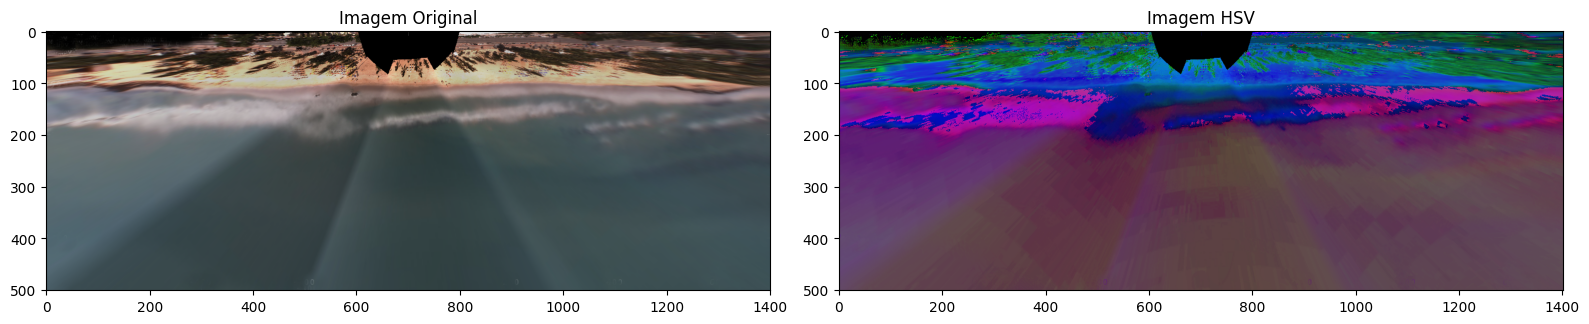

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(img)
ax[0].set_title("Imagem Original")
# ax[0].axis("off")
ax[1].imshow(img_hsv, cmap="hsv")
ax[1].set_title("Imagem HSV")
# ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-01.png", dpi=400)

supondo um recuo do mar


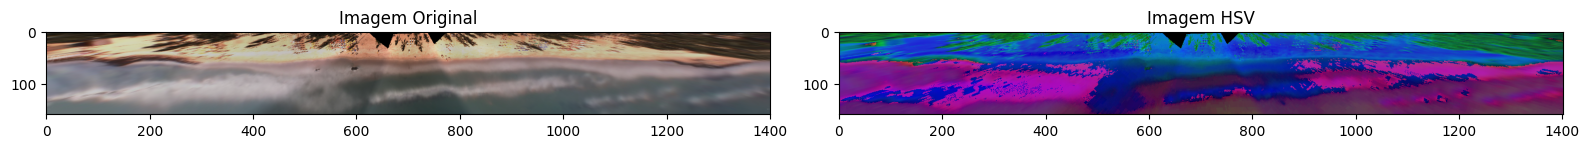

In [45]:
lim_inf = 50
lim_sup = 210

img_cut_org = img[lim_inf:lim_sup, :]
img_cut_hsv = img_hsv[lim_inf:lim_sup, :]
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(img_cut_org)
ax[0].set_title("Imagem Original")
# ax[0].axis("off")
ax[1].imshow(img_cut_hsv, cmap="hsv")   
ax[1].set_title("Imagem HSV")
# ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-02.png", dpi=400)

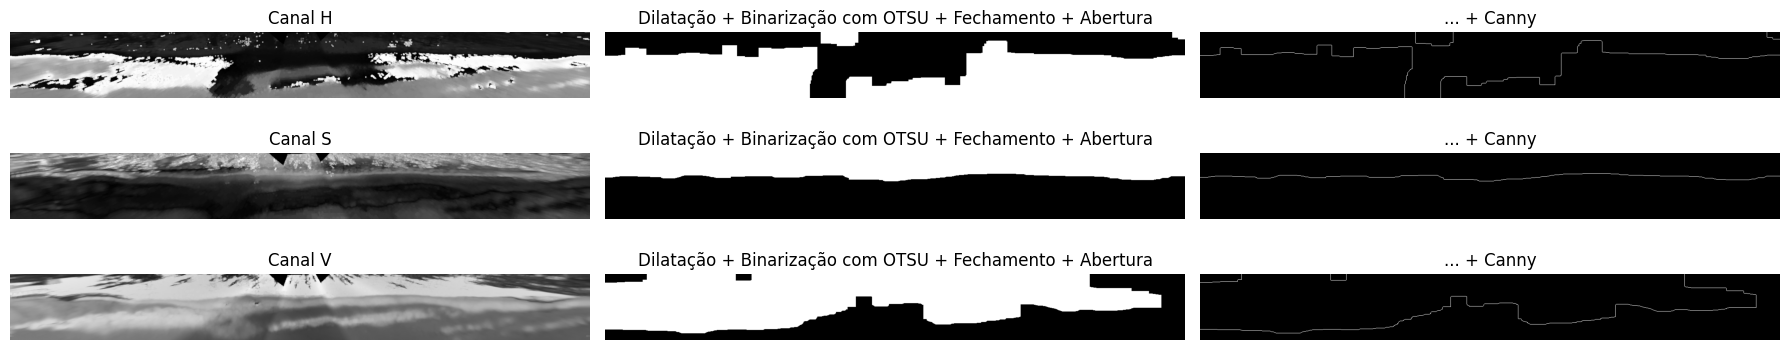

In [46]:
# Converter imagem HSV para preto e branco usando o canal V (Value)
channels = ['H', 'S', 'V']
imgs_bw = []
fig, axes = plt.subplots(3, 3, figsize=(18, 4))

img_cut_hsv = cv2.GaussianBlur(img_cut_hsv, (3, 3), sigmaX=0.5)
kernel = np.ones((7, 7), np.uint8)
# Para cada canal HSV, binarizar e plotar
for i, (ch, name) in enumerate(zip(range(3), channels)):
    channel = img_cut_hsv[:, :, ch]
    
    channel = cv2.dilate(channel, np.ones((3, 3), np.uint8), iterations=1)
    
    _, img_bw = cv2.threshold(channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    img_bw = cv2.morphologyEx(img_bw, cv2.MORPH_CLOSE, kernel, iterations=5)
    img_bw = cv2.morphologyEx(img_bw, cv2.MORPH_OPEN, kernel, iterations=5)

    edges = cv2.Canny(img_bw, threshold1=100, threshold2=200)
    imgs_bw.append(img_bw)
    # Preto e branco

    axes[i, 0].imshow(channel, cmap="gray")
    axes[i, 0].set_title(f"Canal {name}")
    axes[i, 0].axis("off")


    axes[i, 1].imshow(img_bw, cmap="gray")
    axes[i, 1].set_title("Dilatação + Binarização com OTSU + Fechamento + Abertura")
    axes[i, 1].axis("off")
    # Canny
    axes[i, 2].imshow(edges, cmap="gray")
    axes[i, 2].set_title(f"... + Canny")
    axes[i, 2].axis("off")
    # Espaço extra para alinhamento visual
    #axes[i+1, 2].axis("off")

fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-03.png", dpi=400)
plt.show()

In [47]:
# Recorte da imagem original e extração do canal S
img_crop = img[lim_inf:lim_sup]
s_channel = img_cut_hsv[:, :, 1]


# definição dos kernel
kernel_morph = np.ones((7, 7), np.uint8)
kernel_dilate = np.ones((3, 3), np.uint8)

s_channel = cv2.dilate(s_channel, np.ones((3, 3), np.uint8), iterations=1)

_, img_bw = cv2.threshold(
    s_channel,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
img_bw = cv2.morphologyEx(
    img_bw,
    cv2.MORPH_CLOSE,
    kernel_morph,
    iterations=5
)
img_bw = cv2.morphologyEx(
    img_bw,
    cv2.MORPH_OPEN,
    kernel_morph,
    iterations=5
)
edges = cv2.Canny(
    img_bw,
    threshold1=100,
    threshold2=200
)

edges_dilated = cv2.dilate(
    edges,
    kernel_dilate,
    iterations=1
)
# Sobrepor as bordas dilatadas em vermelho sobre a imagem original recortada
img_overlay = img_crop.copy()
img_overlay_dilate = img_crop.copy()
img_overlay[edges > 0] = [255, 255, 255]
img_overlay_dilate[edges_dilated > 0] = [255, 255, 255]

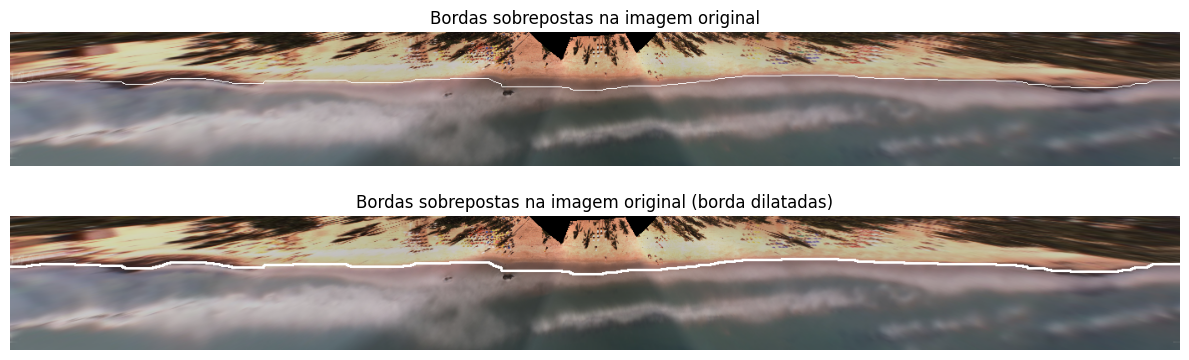

In [48]:
fig, ax = plt.subplots(2, 1, figsize=(12, 4))
ax[0].imshow(img_overlay)
ax[0].set_title("Bordas sobrepostas na imagem original")
ax[0].axis("off")
ax[1].imshow(img_overlay_dilate)
ax[1].set_title("Bordas sobrepostas na imagem original (borda dilatadas)")
ax[1].axis("off")
plt.tight_layout()
plt.savefig(path_assets / "atv03_q05-03.png", dpi=400)

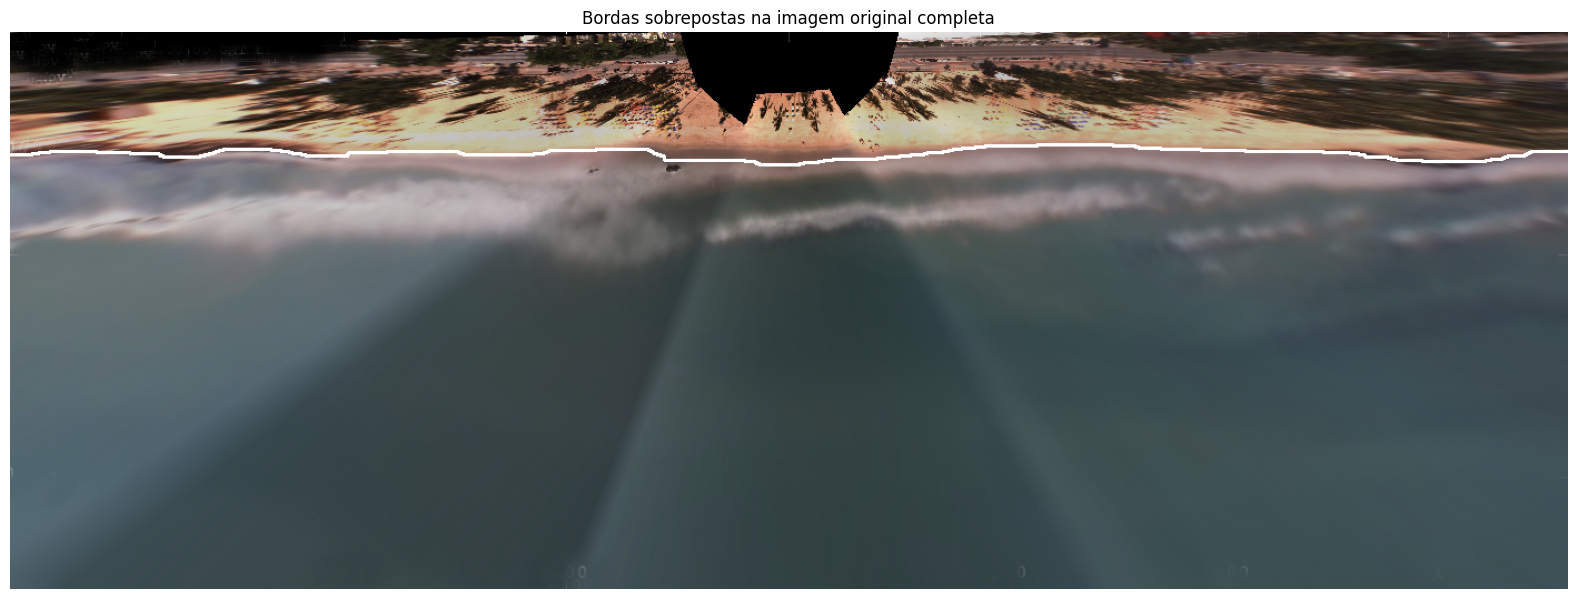

In [49]:
img_full_overlay = img.copy()
img_full_overlay[lim_inf:lim_sup][edges_dilated > 0] = [255, 255, 255]  # vermelho

fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.imshow(img_full_overlay)
ax.set_title("Bordas sobrepostas na imagem original completa")
ax.axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-05.png", dpi=400)
plt.show()


Limiar Otsu encontrado: 92.0


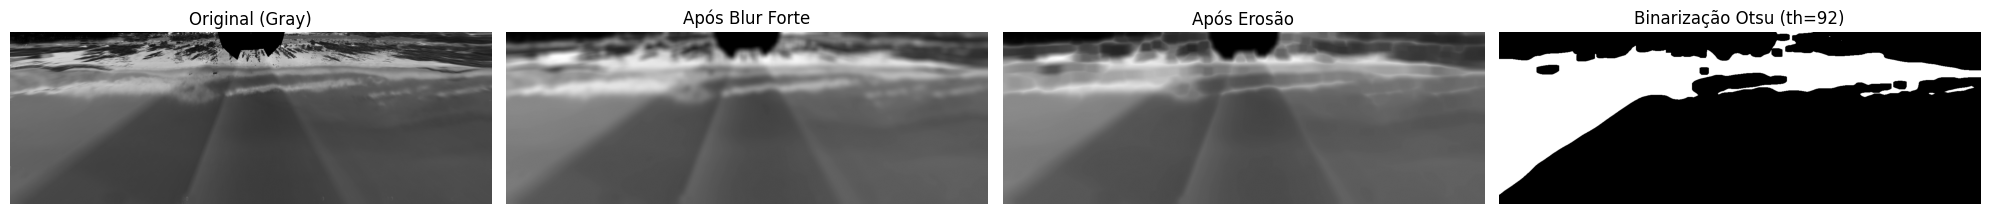

In [50]:
# Aumentar o desfoque (blur) para embassar mais a imagem
img_blur = cv2.GaussianBlur(img_gray, (21, 21), sigmaX=8)

# Erosão para homogeneizar a imagem antes do Otsu
kernel = np.ones((7, 7), np.uint8)
img_eroded = cv2.erode(img_blur, kernel, iterations=2)

# Aplicar Otsu na imagem erodida
thresh_otsu, img_otsu = cv2.threshold(img_eroded, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Limiar Otsu encontrado: {thresh_otsu}")

# Exibir resultado: original, blur, erodida e binarizada
fig, ax = plt.subplots(1, 4, figsize=(20, 6))
ax[0].imshow(img_gray, cmap='gray')
ax[0].set_title("Original (Gray)")
ax[0].axis('off')
ax[1].imshow(img_blur, cmap='gray')
ax[1].set_title("Após Blur Forte")
ax[1].axis('off')
ax[2].imshow(img_eroded, cmap='gray')
ax[2].set_title("Após Erosão")
ax[2].axis('off')
ax[3].imshow(img_otsu, cmap='gray')
ax[3].set_title(f"Binarização Otsu (th={thresh_otsu:.0f})")
ax[3].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
plt.hist(img_gray.flatten(), bins=150)
plt.show()

In [ ]:
plt.imshow(img)

In [ ]:
# Se você quer converter para escala de cinza, use cv2.COLOR_BGR2GRAY
img_processed = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_processed, cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
kernel = np.ones((7, 7), np.uint8) 
kernel += kernel.sum()
img_processed = cv2.erode(img_processed, kernel, iterations=15)
plt.imshow(img_processed, cmap="gray")

In [ ]:
# Aplicar a binarização com um limiar (threshold)
_, binary_image = cv2.threshold(img_processed, 50, 255, cv2.THRESH_BINARY)

# Exibir a imagem original e a binarizada
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Imagem original
ax[0].imshow(img_processed, cmap="gray")
ax[0].set_title("Imagem Original")
# ax[0].axis("off")

# Imagem binarizada
ax[1].imshow(binary_image, cmap="gray")
ax[1].set_title("Imagem Binarizada")
# ax[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Aplicar o detector de bordas Canny na imagem binarizada
edges = cv2.Canny(binary_image, threshold1=100, threshold2=200)

# Exibir a imagem binarizada e as bordas detectadas
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

ax[0].imshow(img, cmap="gray")

# Imagem binarizada
ax[1].imshow(binary_image, cmap="gray")
ax[1].set_title("Imagem Binarizada")
# ax[1].axis("off")

# Bordas detectadas
ax[2].imshow(255 - edges, cmap="gray")
ax[2].set_title("Bordas Detectadas (Canny)")
# ax[2].axis("off")

plt.tight_layout()
plt.show()

dica:  fazer recorte mais proximos do nivel do mar